In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("ecommerce_order_lines_dataset.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(7155, 41)


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 7155
Number of columns: 41

Column names:
['order_line_id', 'order_id', 'order_date', 'customer_id', 'customer_name', 'customer_segment', 'region', 'city_tier', 'channel', 'product_id', 'product_name', 'category', 'quantity', 'unit_price', 'gross_sales', 'discount_pct', 'discount_amount', 'net_revenue', 'product_cost', 'shipping_cost', 'delivery_days', 'delivery_delay', 'payment_method', 'payment_attempted', 'payment_failed', 'return_status', 'return_reason', 'customer_rating', 'satisfaction_score', 'support_contacted', 'marketing_source', 'marketing_channel', 'campaign', 'ad_spend', 'sessions', 'product_views', 'add_to_cart', 'checkout_started', 'total_cost', 'profit', 'profit_margin']


In [3]:
df.head()

,order_line_id,order_id,order_date,customer_id,customer_name,customer_segment,region,city_tier,channel,product_id,...,marketing_channel,campaign,ad_spend,sessions,product_views,add_to_cart,checkout_started,total_cost,profit,profit_margin
0,LINE0000001,ORD000001,2026-05-21,CUST00001,Ayaan Sharma,At-Risk,East,Tier 2,Website,P020,...,Paid Search,G03,586.84,10,6,4,4,14764.54,6765.54,0.3142
1,LINE0000002,ORD000002,2026-04-14,CUST00002,Aditya Sharma,Returning,North,Tier 1,Website,P016,...,Paid Social,M01,201.32,5,5,4,4,3143.88,827.22,0.2083
2,LINE0000003,ORD000003,2026-08-08,CUST00003,Amit Chopra,New,North,Tier 2,Website,P016,...,Organic,O02,37.50,10,5,2,2,2956.10,1934.46,0.3955
3,LINE0000004,ORD000004,2026-07-31,CUST00004,Reyansh Gupta,Returning,West,Tier 3,Mobile App,P018,...,Paid Social,M02,190.33,11,10,1,1,7289.32,2755.13,0.2743
4,LINE0000005,ORD000004,2026-07-31,CUST00004,Reyansh Gupta,Returning,West,Tier 3,Mobile App,P017,...,Paid Social,M02,202.67,11,10,1,1,4472.81,2934.37,0.3962


In [4]:
df.tail()

,order_line_id,order_id,order_date,customer_id,customer_name,customer_segment,region,city_tier,channel,product_id,...,marketing_channel,campaign,ad_spend,sessions,product_views,add_to_cart,checkout_started,total_cost,profit,profit_margin
7150,LINE0007151,ORD004309,2026-06-03,CUST02578,Divya Nair,New,North,Tier 1,Website,P013,...,Organic,O02,35.52,7,2,1,1,3770.40,3156.96,0.4557
7151,LINE0007152,ORD004310,2026-08-12,CUST01780,Anjali Nair,Returning,East,Tier 3,Mobile App,P016,...,Organic,NaN,81.20,11,3,2,2,11502.31,6862.33,0.3737
7152,LINE0007153,ORD004311,2026-04-07,CUST02579,Aarav Chatterjee,New,North,Tier 3,Marketplace,P009,...,Paid Social,M02,2599.20,8,7,3,1,56717.82,4457.58,0.0729
7153,LINE0007154,ORD004311,2026-04-07,CUST02579,Aarav Chatterjee,New,North,Tier 3,Marketplace,P012,...,Paid Social,M02,380.76,8,7,3,1,5394.77,2528.45,0.3191
7154,LINE0007155,ORD004312,2026-03-13,CUST02580,Ananya Verma,At-Risk,East,Tier 2,Mobile App,P009,...,Organic,O03,1294.72,10,10,6,2,271494.32,85951.60,0.2405


In [5]:
print(df.dtypes)

order_line_id          object
order_id               object
order_date             object
customer_id            object
customer_name          object
customer_segment       object
region                 object
city_tier              object
channel                object
product_id             object
product_name           object
category               object
quantity                int64
unit_price            float64
gross_sales           float64
discount_pct          float64
discount_amount       float64
net_revenue           float64
product_cost            int64
shipping_cost         float64
delivery_days         float64
delivery_delay          int64
payment_method         object
payment_attempted       int64
payment_failed          int64
return_status          object
return_reason          object
customer_rating       float64
satisfaction_score      int64
support_contacted      object
marketing_source       object
marketing_channel      object
campaign               object
ad_spend  

In [6]:
data_types = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum().values,
    "unique_values": df.nunique().values
})

print(data_types)

                                column    dtype  missing  unique_values
order_line_id            order_line_id   object        0           7155
order_id                      order_id   object        0           4312
order_date                  order_date   object        0            365
customer_id                customer_id   object        0           2580
customer_name            customer_name   object        0            766
customer_segment      customer_segment   object        0              4
region                          region   object        0             12
city_tier                    city_tier   object        0              3
channel                        channel   object        0              6
product_id                  product_id   object        0             20
product_name              product_name   object        0             20
category                      category   object        0              4
quantity                      quantity    int64        0        

In [7]:
missing = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (
        df.isna().mean().values * 100
    )
})

missing = missing[missing["missing_count"] > 0]

missing = missing.sort_values(
    "missing_percentage",
    ascending=False
)

print(missing)

              column  missing_count  missing_percentage
27   customer_rating             71            0.992313
30  marketing_source             71            0.992313
20     delivery_days             35            0.489168
32          campaign             35            0.489168


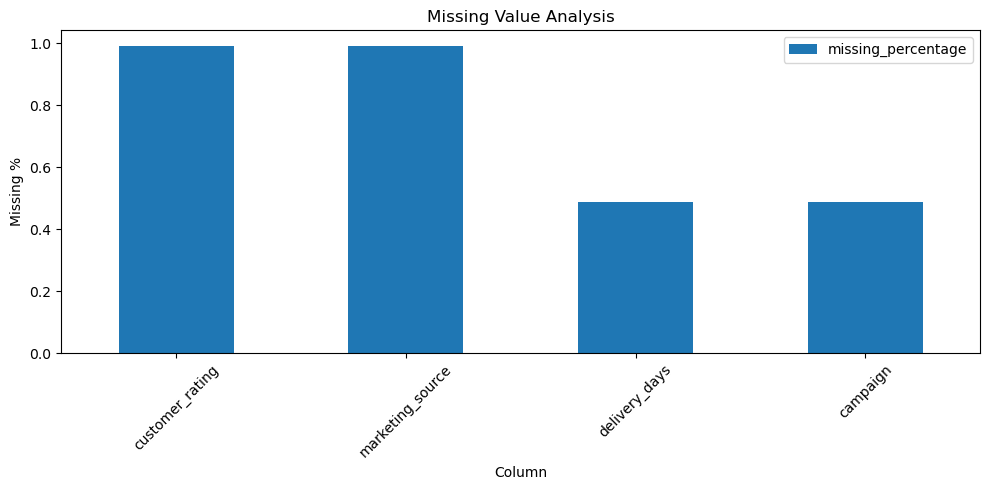

In [8]:
import matplotlib.pyplot as plt

missing.plot(
    x="column",
    y="missing_percentage",
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Missing %")
plt.xlabel("Column")
plt.title("Missing Value Analysis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
duplicate_rows = df.duplicated().sum()

print("Complete duplicate rows:", duplicate_rows)

Complete duplicate rows: 0


In [10]:
duplicate_order_lines = df["order_line_id"].duplicated().sum()

print("Duplicate order_line_id:", duplicate_order_lines)

Duplicate order_line_id: 0


In [12]:
order_counts = df.groupby("order_id").size()

print(order_counts.describe())

count    4312.000000
mean        1.659323
std         0.731462
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
dtype: float64


In [13]:
multi_line_orders = (order_counts > 1).sum()

print("Orders with multiple product lines:", multi_line_orders)

Orders with multiple product lines: 2174


In [14]:
print(
    df["order_id"].value_counts().head(10)
)

order_id
ORD004303    3
ORD004304    3
ORD000004    3
ORD002163    3
ORD002172    3
ORD000020    3
ORD002182    3
ORD004249    3
ORD004256    3
ORD000006    3
Name: count, dtype: int64


In [15]:
df["order_line_id"].nunique()

7155

In [17]:
df["order_id"].nunique()

4312

In [18]:
print(
    "Unique customers:",
    df["customer_id"].nunique()
)

print(
    "Unique orders:",
    df["order_id"].nunique()
)

print(
    "Unique order lines:",
    df["order_line_id"].nunique()
)

Unique customers: 2580
Unique orders: 4312
Unique order lines: 7155


In [19]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

In [20]:
invalid_dates = df["order_date"].isna().sum()

print("Invalid dates:", invalid_dates)

Invalid dates: 0


In [21]:
print("Minimum date:", df["order_date"].min())
print("Maximum date:", df["order_date"].max())

Minimum date: 2026-01-01 00:00:00
Maximum date: 2026-12-31 00:00:00


In [22]:
invalid_quantity = df[
    (df["quantity"] <= 0) |
    (df["quantity"].isna())
]

print("Invalid quantity records:", len(invalid_quantity))

Invalid quantity records: 0


In [23]:
invalid_price = df[
    (df["unit_price"] <= 0) |
    (df["unit_price"].isna())
]

print("Invalid unit prices:", len(invalid_price))

Invalid unit prices: 0


In [24]:
invalid_discount = df[
    (df["discount_pct"] < 0) |
    (df["discount_pct"] > 1)
]

print("Invalid discount records:", len(invalid_discount))

Invalid discount records: 0


In [25]:
print(df["region"].value_counts(dropna=False))
print(df["channel"].value_counts(dropna=False))
print(df["category"].value_counts(dropna=False))
print(df["payment_method"].value_counts(dropna=False))
print(df["return_status"].value_counts(dropna=False))

region
North    2020
West     1789
South    1637
East     1566
north      23
NORTH      23
WEST       23
SOUTH      17
west       15
east       14
EAST       14
south      14
Name: count, dtype: int64
channel
Website        3092
Mobile App     2382
Marketplace    1530
mobile app       51
Mobile_App       50
MOBILE APP       50
Name: count, dtype: int64
category
Accessories    4192
Computing      1956
Mobile          579
Electronics     428
Name: count, dtype: int64
payment_method
UPI                 2416
Credit Card         1468
Debit Card          1335
Net Banking          734
Cash on Delivery     647
Wallet               555
Name: count, dtype: int64
return_status
No     6663
Yes     492
Name: count, dtype: int64


In [26]:
categorical_columns = [
    "region",
    "channel",
    "category",
    "payment_method",
    "return_status",
    "marketing_source",
    "marketing_channel",
    "campaign"
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))


region
region
North    2020
West     1789
South    1637
East     1566
north      23
NORTH      23
WEST       23
SOUTH      17
west       15
east       14
EAST       14
south      14
Name: count, dtype: int64

channel
channel
Website        3092
Mobile App     2382
Marketplace    1530
mobile app       51
Mobile_App       50
MOBILE APP       50
Name: count, dtype: int64

category
category
Accessories    4192
Computing      1956
Mobile          579
Electronics     428
Name: count, dtype: int64

payment_method
payment_method
UPI                 2416
Credit Card         1468
Debit Card          1335
Net Banking          734
Cash on Delivery     647
Wallet               555
Name: count, dtype: int64

return_status
return_status
No     6663
Yes     492
Name: count, dtype: int64

marketing_source
marketing_source
Google Ads    2335
Meta Ads      2086
Organic       1392
Email         1271
NaN             71
Name: count, dtype: int64

marketing_channel
marketing_channel
Paid Search    2360
Paid

In [27]:
df["gross_sales_check"] = (
    df["quantity"] *
    df["unit_price"]
)


gross_error = (
    df["gross_sales"] -
    df["gross_sales_check"]
).abs()

print(
    "Maximum gross sales error:",
    gross_error.max()
)

Maximum gross sales error: 0.0


In [28]:
df["discount_amount_check"] = (
    df["gross_sales"] *
    df["discount_pct"]
)



discount_error = (
    df["discount_amount"] -
    df["discount_amount_check"]
).abs()

print(
    "Maximum discount error:",
    discount_error.max()
)

Maximum discount error: 16.31999999999971


In [29]:
print(
    "Discount reconciliation:",
    np.allclose(
        df["discount_amount"],
        df["discount_amount_check"],
        atol=0.01
    )
)


Discount reconciliation: False


In [31]:
df["net_revenue_check"] = (
    df["gross_sales"] -
    df["discount_amount"]
)



revenue_error = (
    df["net_revenue"] -
    df["net_revenue_check"]
).abs()

print(
    "Maximum net revenue error:",
    revenue_error.max()
)

Maximum net revenue error: 2.9103830456733704e-11


In [32]:
print(df["product_cost"].describe())



invalid_cost = df[
    (df["product_cost"] < 0) |
    (df["product_cost"].isna())
]

print(
    "Invalid product cost records:",
    len(invalid_cost)
)

count      7155.000000
mean      14021.132075
std       20147.644241
min         900.000000
25%        3500.000000
50%        7000.000000
75%       14400.000000
max      504000.000000
Name: product_cost, dtype: float64
Invalid product cost records: 0


In [33]:
df["total_cost_check"] = (
    df["product_cost"] +
    df["shipping_cost"] +
    df["ad_spend"]
)
cost_error = (
    df["total_cost"] -
    df["total_cost_check"]
).abs()

print(
    "Maximum total cost error:",
    cost_error.max()
)

Maximum total cost error: 5.820766091346741e-11


In [34]:
df["profit_check"] = (
    df["net_revenue"] -
    df["total_cost"]
)
profit_error = (
    df["profit"] -
    df["profit_check"]
).abs()

print(
    "Maximum profit error:",
    profit_error.max()
)

Maximum profit error: 4.3655745685100555e-11


In [35]:
df["profit_margin_check"] = (
    df["profit"] /
    df["net_revenue"]
)



margin_error = (
    df["profit_margin"] -
    df["profit_margin_check"]
).abs()

print(
    "Maximum profit margin error:",
    margin_error.max()
)

Maximum profit margin error: 4.9998300510556426e-05


In [38]:
negative_revenue = df[
    df["net_revenue"] < 0
]

print(
    "Negative revenue records:",
    len(negative_revenue)
)

Negative revenue records: 0


In [39]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns.tolist())

['quantity', 'unit_price', 'gross_sales', 'discount_pct', 'discount_amount', 'net_revenue', 'product_cost', 'shipping_cost', 'delivery_days', 'delivery_delay', 'payment_attempted', 'payment_failed', 'customer_rating', 'satisfaction_score', 'ad_spend', 'sessions', 'product_views', 'add_to_cart', 'checkout_started', 'total_cost', 'profit', 'profit_margin', 'gross_sales_check', 'discount_amount_check', 'net_revenue_check', 'total_cost_check', 'profit_check', 'profit_margin_check']


In [40]:
def detect_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]
    
    return outliers, lower, upper

In [41]:
outliers, lower, upper = detect_outliers(
    df,
    "shipping_cost"
)

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Outliers:", len(outliers))

Lower limit: -90.21499999999997
Upper limit: 290.18499999999995
Outliers: 2


In [42]:
important_columns = [
    "net_revenue",
    "shipping_cost",
    "ad_spend",
    "discount_pct",
    "delivery_days",
    "quantity",
    "profit",
    "profit_margin"
]

for col in important_columns:
    
    outliers, lower, upper = detect_outliers(
        df,
        col
    )
    
    print(
        f"{col}: {len(outliers)} outliers"
    )

net_revenue: 658 outliers
shipping_cost: 2 outliers
ad_spend: 626 outliers
discount_pct: 0 outliers
delivery_days: 418 outliers
quantity: 14 outliers
profit: 349 outliers
profit_margin: 135 outliers


In [43]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_pct": (
        df.isna().mean().values * 100
    ),
    "unique_count": df.nunique().values
})

quality_report

,column,dtype,missing_count,missing_pct,unique_count
order_line_id,order_line_id,object,0,0.000000,7155
order_id,order_id,object,0,0.000000,4312
order_date,order_date,datetime64[ns],0,0.000000,365
customer_id,customer_id,object,0,0.000000,2580
customer_name,customer_name,object,0,0.000000,766
customer_segment,customer_segment,object,0,0.000000,4
region,region,object,0,0.000000,12
city_tier,city_tier,object,0,0.000000,3
channel,channel,object,0,0.000000,6
product_id,product_id,object,0,0.000000,20


In [44]:
quality_report.to_csv(
    "data_quality_report.csv",
    index=False
)

In [45]:
print("========== DATA QUALITY SUMMARY ==========")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print(
    "Duplicate complete rows:",
    df.duplicated().sum()
)

print(
    "Duplicate order_line_id:",
    df["order_line_id"].duplicated().sum()
)

print(
    "Invalid dates:",
    df["order_date"].isna().sum()
)

print(
    "Negative revenue:",
    (df["net_revenue"] < 0).sum()
)

print(
    "Negative profit:",
    (df["profit"] < 0).sum()
)

print(
    "Gross sales valid:",
    np.allclose(
        df["gross_sales"],
        df["quantity"] * df["unit_price"],
        atol=0.01
    )
)

print(
    "Net revenue valid:",
    np.allclose(
        df["net_revenue"],
        df["gross_sales"] - df["discount_amount"],
        atol=0.01
    )
)

print(
    "Total cost valid:",
    np.allclose(
        df["total_cost"],
        df["product_cost"] +
        df["shipping_cost"] +
        df["ad_spend"],
        atol=0.01
    )
)

print(
    "Profit valid:",
    np.allclose(
        df["profit"],
        df["net_revenue"] - df["total_cost"],
        atol=0.01
    )
)

print("==========================================")

========== DATA QUALITY SUMMARY ==========
Rows: 7155
Columns: 47
Duplicate complete rows: 0
Duplicate order_line_id: 0
Invalid dates: 0
Negative revenue: 0
Negative profit: 14
Gross sales valid: True
Net revenue valid: True
Total cost valid: True
Profit valid: True


In [46]:
categorical_columns = [
    "region",
    "channel",
    "category",
    "payment_method",
    "return_status",
    "return_reason",
    "customer_segment",
    "city_tier",
    "support_contacted",
    "marketing_source",
    "marketing_channel",
    "campaign"
]

for col in categorical_columns:
    df[col] = df[col].astype("string").str.strip()

In [47]:
for col in categorical_columns:
    df[col] = df[col].str.title()

In [48]:
df.isna().sum().sort_values(ascending=False)

customer_rating          71
marketing_source         71
delivery_days            35
campaign                 35
order_line_id             0
order_id                  0
order_date                0
city_tier                 0
channel                   0
product_id                0
product_name              0
customer_id               0
customer_name             0
customer_segment          0
region                    0
gross_sales               0
unit_price                0
quantity                  0
category                  0
product_cost              0
shipping_cost             0
net_revenue               0
discount_pct              0
payment_method            0
delivery_delay            0
payment_attempted         0
payment_failed            0
return_reason             0
return_status             0
satisfaction_score        0
discount_amount           0
support_contacted         0
marketing_channel         0
ad_spend                  0
sessions                  0
product_views       

In [50]:
df["delivery_days"] = df["delivery_days"].fillna(
    df["delivery_days"].median()
)

In [51]:
df["customer_rating"] = df["customer_rating"].fillna(
    df["customer_rating"].median()
)

In [54]:
df["campaign"] = df["campaign"].fillna(
    "Unknown"
)

In [52]:
df["marketing_source"] = df["marketing_source"].fillna(
    "Unknown"
)

In [55]:
print(df.isna().sum().sum())

0


In [56]:
df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

df["quarter"] = df["order_date"].dt.quarter

df["week"] = df["order_date"].dt.isocalendar().week

df["day_of_week"] = df["order_date"].dt.day_name()

df["day_of_month"] = df["order_date"].dt.day

In [57]:
df["is_weekend"] = (
    df["order_date"].dt.dayofweek >= 5
).astype(int)

In [59]:
df[
    [
        "order_date",
        "year",
        "month",
        "month_name",
        "quarter",
        "day_of_week",
        "is_weekend"
    ]
].head()

,order_date,year,month,month_name,quarter,day_of_week,is_weekend
0,2026-05-21,2026,5,May,2,Thursday,0
1,2026-04-14,2026,4,April,2,Tuesday,0
2,2026-08-08,2026,8,August,3,Saturday,1
3,2026-07-31,2026,7,July,3,Friday,0
4,2026-07-31,2026,7,July,3,Friday,0


In [60]:
df["discount_value"] = (
    df["gross_sales"] *
    df["discount_pct"]
)

df["revenue_after_discount"] = (
    df["gross_sales"] -
    df["discount_value"]
)
df["shipping_cost_pct"] = np.where(
    df["net_revenue"] > 0,
    df["shipping_cost"] /
    df["net_revenue"],
    0
)
df["marketing_cost_pct"] = np.where(
    df["net_revenue"] > 0,
    df["ad_spend"] /
    df["net_revenue"],
    0
)

In [66]:
df["return_flag"] = (
    df["return_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("returned")
    .astype(int)
)

In [67]:
df["return_flag"].value_counts()

return_flag
0    7155
Name: count, dtype: int64

In [73]:
df["payment_failure_flag"] = (
    df["payment_failed"] > 0
).astype(int)


df["delivery_delay_flag"] = (
    df["delivery_delay"] > 0
).astype(int)




df["negative_profit_flag"] = (
    df["profit"] < 0
).astype(int)



print(
    "Loss-making lines:",
    df["negative_profit_flag"].sum()
)




df["high_discount_flag"] = (
    df["discount_pct"] >= 0.15
).astype(int)






shipping_threshold = df["shipping_cost"].quantile(0.90)

df["high_shipping_cost_flag"] = (
    df["shipping_cost"] >= shipping_threshold
).astype(int)

print("Shipping threshold:", shipping_threshold)




df["low_rating_flag"] = (
    df["customer_rating"] <= 2
).astype(int)

Loss-making lines: 14
Shipping threshold: 175.76


In [74]:
customer_features = df.groupby(
    "customer_id"
).agg(
    customer_orders=("order_id", "nunique"),
    customer_revenue=("net_revenue", "sum"),
    customer_profit=("profit", "sum"),
    customer_return_rate=("return_flag", "mean"),
    customer_avg_rating=("customer_rating", "mean")
).reset_index()

In [75]:
customer_features.head()

,customer_id,customer_orders,customer_revenue,customer_profit,customer_return_rate,customer_avg_rating
0,CUST00001,4,210322.91,34832.98,0.0,5.000000
1,CUST00002,12,583775.75,141180.10,0.0,4.100000
2,CUST00003,3,72340.80,22355.04,0.0,4.750000
3,CUST00004,11,338613.95,57294.91,0.0,4.062500
4,CUST00005,14,593318.45,147803.93,0.0,4.130435


In [76]:
df = df.merge(
    customer_features,
    on="customer_id",
    how="left"
)

In [77]:
order_features = df.groupby(
    "order_id"
).agg(
    order_revenue=("net_revenue", "sum"),
    order_profit=("profit", "sum"),
    order_lines=("order_line_id", "count"),
    order_quantity=("quantity", "sum"),
    order_return_flag=("return_flag", "max")
).reset_index()

In [78]:
df = df.merge(
    order_features,
    on="order_id",
    how="left"
)

In [79]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7155
Columns: 76


In [82]:
print(df.head())

  order_line_id   order_id order_date customer_id  customer_name  \
0   LINE0000001  ORD000001 2026-05-21   CUST00001   Ayaan Sharma   
1   LINE0000002  ORD000002 2026-04-14   CUST00002  Aditya Sharma   
2   LINE0000003  ORD000003 2026-08-08   CUST00003    Amit Chopra   
3   LINE0000004  ORD000004 2026-07-31   CUST00004  Reyansh Gupta   
4   LINE0000005  ORD000004 2026-07-31   CUST00004  Reyansh Gupta   

  customer_segment region city_tier     channel product_id  ...  \
0          At-Risk   East    Tier 2     Website       P020  ...   
1        Returning  North    Tier 1     Website       P016  ...   
2              New  North    Tier 2     Website       P016  ...   
3        Returning   West    Tier 3  Mobile App       P018  ...   
4        Returning   West    Tier 3  Mobile App       P017  ...   

  customer_orders customer_revenue  customer_profit  customer_return_rate  \
0               4        210322.91         34832.98                   0.0   
1              12        583775.75

In [83]:
print(
    df.isna().sum()
    .sort_values(ascending=False)
    .head(10)
)

order_line_id       0
order_id            0
order_date          0
customer_id         0
customer_name       0
customer_segment    0
region              0
city_tier           0
channel             0
product_id          0
dtype: int64


In [84]:
validation_columns = [
    "gross_sales_check",
    "discount_amount_check",
    "net_revenue_check",
    "total_cost_check",
    "profit_check",
    "profit_margin_check"
]

df = df.drop(
    columns=[
        col for col in validation_columns
        if col in df.columns
    ]
)

In [85]:
print(
    "Duplicate order lines:",
    df["order_line_id"].duplicated().sum()
)

Duplicate order lines: 0


In [87]:
categorical_cols = [
    "region",
    "city_tier",
    "channel",
    "product_name",
    "category",
    "payment_method",
    "return_status",
    "return_reason",
    "customer_segment",
    "marketing_source",
    "marketing_channel",
    "campaign"
]

# Standardize categorical columns
for col in categorical_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .str.title()
        )

# Check region
print(df["region"].value_counts(dropna=False))

region
North    2066
West     1827
South    1668
East     1594
Name: count, dtype: Int64


In [88]:
categorical_columns = [
    "region",
    "channel",
    "category",
    "payment_method",
    "return_status",
    "marketing_source",
    "marketing_channel",
    "campaign"
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))


region
region
North    2066
West     1827
South    1668
East     1594
Name: count, dtype: Int64

channel
channel
Website        3092
Mobile App     2483
Marketplace    1530
Mobile_App       50
Name: count, dtype: Int64

category
category
Accessories    4192
Computing      1956
Mobile          579
Electronics     428
Name: count, dtype: Int64

payment_method
payment_method
Upi                 2416
Credit Card         1468
Debit Card          1335
Net Banking          734
Cash On Delivery     647
Wallet               555
Name: count, dtype: Int64

return_status
return_status
No     6663
Yes     492
Name: count, dtype: Int64

marketing_source
marketing_source
Google Ads    2335
Meta Ads      2086
Organic       1392
Email         1271
Unknown         71
Name: count, dtype: Int64

marketing_channel
marketing_channel
Paid Search    2360
Paid Social    2106
Organic        1405
Email          1284
Name: count, dtype: Int64

campaign
campaign
G03        811
G02        790
G01        749
M01   

In [90]:
df["channel"] = (
    df["channel"]
    .astype("string")
    .str.strip()
    .replace({
        "Mobile_App": "Mobile App"
    })
)

print(df["channel"].value_counts())

channel
Website        3092
Mobile App     2533
Marketplace    1530
Name: count, dtype: Int64


In [91]:
output_path = "ecommerce_cleaned.csv"

df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ecommerce_cleaned.csv


In [92]:
print("Shape:", df.shape)

Shape: (7155, 70)
